# 02 — Baseline Temporal (Walk-Forward por Temporada) — Brasileirão

**Objetivo:** medir, com validação estritamente temporal (sem shuffle), o LogLoss multiclasse de dois
modelos simples: (1) frequência histórica de classes e (2) regressão logística multinomial, usando apenas
features permitidas pelas regras do projeto.

**Decisões e regras seguidas nesta notebook**:
- Usamos **apenas `train.csv`** (temporadas 2013–2021). `test.csv` não tem `Res`, então não pode ser usado
  para calcular LogLoss — a validação walk-forward é feita inteiramente dentro de `train.csv`. `test.csv`
  não é carregado nesta notebook; ele será usado somente na notebook de geração da submissão final.
- Validação **walk-forward por `Season`, sem shuffle**: para cada temporada de validação, o treino usa
  apenas temporadas estritamente anteriores (expanding window). Nenhum `train_test_split(shuffle=True)`
  nem k-fold aleatório é usado.
- Janela de aquecimento (*warm-up*) de 3 temporadas (2013–2015): a primeira temporada de validação é 2016,
  garantindo histórico mínimo antes de validar (conforme visto na EDA, as primeiras rodadas de uma temporada
  têm mais NaN em features de forma/histórico).
- **Odds (`odd_casa`/`odd_empate`/`odd_visitante`) não entram no conjunto de features** — ficam fora do
  pipeline por completo (regra 5).
- `Home`/`Away` (identidade dos times) **não são usados nesta baseline** — o encoding de time fica para uma
  notebook futura mais avançada; aqui o objetivo é um baseline simples com features numéricas pré-jogo.
- Todo `SimpleImputer`/`StandardScaler` é ajustado **apenas no treino de cada fold**.
- `RANDOM_STATE` fixo para reprodutibilidade.
- `CLASS_ORDER = ['A', 'D', 'H']` é usado em todo lugar que envolve `log_loss` ou `predict_proba`, com
  reindexação explícita — nunca assumindo a ordem interna do modelo.


In [1]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
CLASS_ORDER = ['A', 'D', 'H']

train = pd.read_csv('../data/train.csv')
train = train.sort_values(['Season', 'Date', 'Id']).reset_index(drop=True)

assert train['Id'].is_monotonic_increasing, 'train não está em ordem cronológica por Id'
print('train shape:', train.shape)
print('temporadas:', sorted(train['Season'].unique()))


train shape: (3419, 26)
temporadas: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]


## Features permitidas

In [2]:
FEATURES = [
    'elo_home', 'elo_away', 'elo_diff',
    'form_pts_home', 'form_pts_away',
    'form_gf_home', 'form_ga_home', 'form_gf_away', 'form_ga_away',
    'home_form_as_host', 'away_form_as_visitor',
    'rest_days_home', 'rest_days_away',
    'season_ppg_home', 'season_ppg_away',
    'round_n', 'h2h_home_pts',
]

# Explicitamente EXCLUÍDAS do pipeline de modelagem:
EXCLUDED = ['Id', 'Date', 'Home', 'Away', 'Res', 'odd_casa', 'odd_empate', 'odd_visitante']

assert set(FEATURES).isdisjoint(EXCLUDED)
assert set(FEATURES).issubset(train.columns)
print(f'{len(FEATURES)} features numéricas pré-jogo selecionadas.')
FEATURES


17 features numéricas pré-jogo selecionadas.


['elo_home',
 'elo_away',
 'elo_diff',
 'form_pts_home',
 'form_pts_away',
 'form_gf_home',
 'form_ga_home',
 'form_gf_away',
 'form_ga_away',
 'home_form_as_host',
 'away_form_as_visitor',
 'rest_days_home',
 'rest_days_away',
 'season_ppg_home',
 'season_ppg_away',
 'round_n',
 'h2h_home_pts']

## Esquema de validação walk-forward por temporada

In [3]:
seasons = sorted(train['Season'].unique())
MIN_TRAIN_SEASONS = 3  # 2013-2015 como aquecimento mínimo
validation_seasons = seasons[MIN_TRAIN_SEASONS:]  # 2016..2021

print('Temporadas de treino inicial (aquecimento):', seasons[:MIN_TRAIN_SEASONS])
print('Temporadas usadas para validação (expanding window):', validation_seasons)


Temporadas de treino inicial (aquecimento): [np.int64(2013), np.int64(2014), np.int64(2015)]
Temporadas usadas para validação (expanding window): [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]


Para cada `val_season` em `validation_seasons`, o fold é:
- **treino** = todas as linhas com `Season < val_season`
- **validação** = todas as linhas com `Season == val_season`

Isso é uma *expanding window*: a cada temporada validada, o treino cresce incorporando a temporada anterior,
nunca olhando para o futuro.


In [4]:
def historical_frequency_baseline(y_train, n_val):
    """Probabilidades constantes = frequência de classes observada apenas no treino do fold."""
    counts = y_train.value_counts()
    freq = pd.Series(0.0, index=CLASS_ORDER)
    for cls in CLASS_ORDER:
        freq[cls] = counts.get(cls, 0) / len(y_train)
    proba = np.tile(freq.values, (n_val, 1))
    return proba


def build_logreg_pipeline():
    preprocess = ColumnTransformer([
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
        ]), FEATURES),
    ])
    model = Pipeline([
        ('preprocess', preprocess),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])
    return model


def predict_proba_ordered(model, X):
    """Reindexa predict_proba para CLASS_ORDER, nunca assume a ordem interna do modelo."""
    raw = model.predict_proba(X)
    raw_df = pd.DataFrame(raw, columns=model.named_steps['clf'].classes_)
    return raw_df[CLASS_ORDER].values


## Loop de validação walk-forward

In [5]:
results = []

for val_season in validation_seasons:
    train_fold = train[train['Season'] < val_season]
    val_fold = train[train['Season'] == val_season]

    X_train, y_train = train_fold[FEATURES], train_fold['Res']
    X_val, y_val = val_fold[FEATURES], val_fold['Res']

    # --- Baseline 1: frequência histórica (ajustada só no treino do fold) ---
    proba_freq = historical_frequency_baseline(y_train, len(val_fold))
    ll_freq = log_loss(y_val, proba_freq, labels=CLASS_ORDER)

    # --- Baseline 2: regressão logística multinomial ---
    model = build_logreg_pipeline()
    model.fit(X_train, y_train)
    proba_logreg = predict_proba_ordered(model, X_val)
    ll_logreg = log_loss(y_val, proba_logreg, labels=CLASS_ORDER)

    results.append({
        'Season': val_season,
        'n_train': len(train_fold),
        'n_val': len(val_fold),
        'LogLoss_freq': ll_freq,
        'LogLoss_logreg': ll_logreg,
    })

results_df = pd.DataFrame(results)
results_df


,Season,n_train,n_val,LogLoss_freq,LogLoss_logreg
0,2016,1140,379,1.014974,1.011880
1,2017,1519,380,1.087350,1.108701
2,2018,1899,380,1.014843,0.985679
3,2019,2279,380,1.052040,0.997673
4,2020,2659,380,1.074666,1.058805
5,2021,3039,380,1.066302,1.039465


## LogLoss por temporada e média final

In [6]:
summary = pd.DataFrame({
    'mean (simples)': [results_df['LogLoss_freq'].mean(), results_df['LogLoss_logreg'].mean()],
    'mean (ponderada por n_val)': [
        np.average(results_df['LogLoss_freq'], weights=results_df['n_val']),
        np.average(results_df['LogLoss_logreg'], weights=results_df['n_val']),
    ],
}, index=['Frequência histórica', 'Regressão logística multinomial'])

print('LogLoss por temporada:')
display(results_df.set_index('Season')[['LogLoss_freq', 'LogLoss_logreg']])

print()
print('Médias finais:')
display(summary)


LogLoss por temporada:


,LogLoss_freq,LogLoss_logreg
Season,,
2016,1.014974,1.011880
2017,1.087350,1.108701
2018,1.014843,0.985679
2019,1.052040,0.997673
2020,1.074666,1.058805
2021,1.066302,1.039465



Médias finais:


,mean (simples),mean (ponderada por n_val)
Frequência histórica,1.051696,1.051712
Regressão logística multinomial,1.033700,1.033710


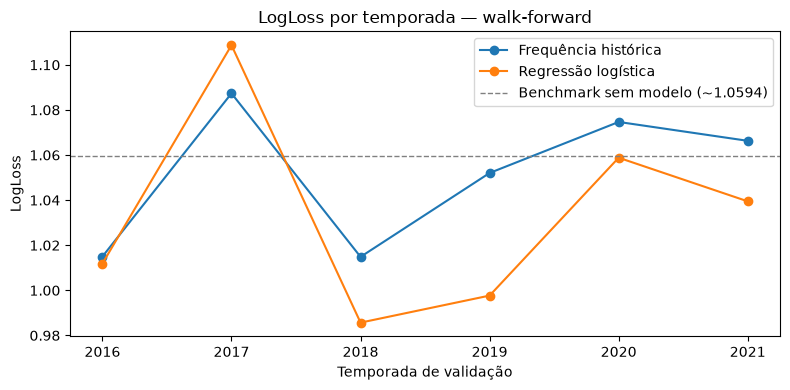

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_df['Season'], results_df['LogLoss_freq'], marker='o', label='Frequência histórica')
ax.plot(results_df['Season'], results_df['LogLoss_logreg'], marker='o', label='Regressão logística')
ax.axhline(1.0594, color='gray', linestyle='--', linewidth=1, label='Benchmark sem modelo (~1.0594)')
ax.set_xlabel('Temporada de validação')
ax.set_ylabel('LogLoss')
ax.set_title('LogLoss por temporada — walk-forward')
ax.legend()
plt.tight_layout()
plt.show()


## Discussão

- A regressão logística multinomial usa apenas features pré-jogo permitidas (Elo, forma recente, descanso,
  desempenho na temporada, confronto direto) — nenhuma odd e nenhuma linha de `test.csv` foi usada.
- O baseline de frequência histórica é recalculado a cada fold (não é uma frequência global fixa), então já
  reflete a distribuição de `Res` observada até aquele ponto no tempo.
- Compare a média final de cada abordagem com o benchmark sem modelo (~1.0594, do enunciado) e com o
  baseline inicial (~1.047): valores de LogLoss abaixo de ~1.000 devem ser tratados como suspeitos e
  investigados quanto a vazamento antes de serem aceitos.
- Esta notebook **não gera nenhum arquivo de submissão** — o objetivo aqui é validar a estratégia temporal e
  comparar as duas abordagens. A geração da submissão final (`submissions/`) usando `test.csv` fica para uma
  notebook seguinte, reaproveitando o pipeline validado aqui.
